In [70]:
import csv
import inflect
import os
import pathlib
import torch

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from minicons import scorer
from nltk.corpus import wordnet as wn
from sklearn.decomposition import PCA
from transformers import set_seed
from wordfreq import word_frequency

Notes:

1. find known singular and plural nouns in the model's vocabulary, and store their embeddings separately.
2. fit pca to these embeddings
3. load wug embeddings, including ones from different checkpoints?
4. project wug embeddings into pca space
5. (Optional): load init embeddings using seeds
5. visualize 

In [2]:
# get hf token
hf_token = os.getenv("HF_TOKEN")

In [ ]:
model = "Qwen/Qwen3-VL-4B-Instruct"
model_name = model.replace("/", "_")

lm = scorer.VLMScorer(model, device="cuda:0", token=hf_token)

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.49it/s]


In [4]:
embs = lm.model.model.language_model.embed_tokens.weight.detach().cpu()

In [5]:
# start with loading the top 1000 most common paired singular and plural nouns (e.g., 1000 each) that occur in qwen vocabulary
p = inflect.engine()

In [6]:
def is_single_token(word):
    tokens = lm.tokenizer.tokenizer(f' {word}', add_special_tokens=False)['input_ids']
    return len(tokens) == 1

In [7]:
banned = ['physics', 'subs', 'roma', 'pois', 'arts', 'tors', 'ours', 'autos', 'jeans', 'aras', 'cocos']

def get_unambiguous_nouns(n=10, min_noun_ratio=1.0):
    """
    n: Number of items to return.
    min_noun_ratio: 1.0 means ONLY nouns allowed. 
                    0.7 means at least 70% of WordNet senses must be nouns.
    """
    target_categories = {
        'noun.animal', 'noun.artifact', 'noun.object', 'noun.plant', 'noun.food'
    }
    
    all_valid_candidates = []
    
    # Iterate through noun lemmas
    for lemma_name in wn.all_lemma_names(pos=wn.NOUN):
        lemma_name = lemma_name.lower()
        
        # 1. Basic Cleaning
        if "_" in lemma_name or "-" in lemma_name or not lemma_name.isalpha():
            continue
            
        # 2. Part of Speech Dominance Check
        all_senses = wn.synsets(lemma_name)
        if lemma_name == 'dog':
            print(all_senses)
        noun_senses = [s for s in all_senses if s.pos() == 'n']
        if lemma_name == 'dog':
            print(noun_senses)
        
        # Calculate ratio of noun senses to total senses
        # (e.g., if 'dog' has 7 noun senses and 1 verb sense, ratio is 0.875)
        noun_ratio = len(noun_senses) / len(all_senses) if all_senses else 0
        if lemma_name == 'dog':
            print(f"Noun Ratio for 'dog': {noun_ratio}")
        
        if noun_ratio < min_noun_ratio:
            continue

        # 3. Category Filter (Check the most frequent noun sense)
        # We ensure the primary noun meaning is one of your target categories
        primary_noun_sense = noun_senses[0]
        if primary_noun_sense.lexname() not in target_categories:
            if lemma_name == 'dog':
                print(f"Primary noun sense for 'dog' is not in target categories: {primary_noun_sense.lexname()}")
            continue

        # 4. Proper Noun Guard
        # if any(l.name()[0].isupper() for l in primary_noun_sense.lemmas()):
        #     if lemma_name == 'dog':
        #         print(f"'dog' is being filtered out as a proper noun, which is unexpected.")
        #     continue
        if lemma_name[0].isupper():
            if lemma_name == 'dog':
                print(f"'dog' is being filtered out as a proper noun, which is unexpected.")
            continue

        # 5. Pluralization & Tokenization (The Double-Single-Token constraint)
        if p.singular_noun(lemma_name) is False:
            plural_form = p.plural(lemma_name)

            if lemma_name != plural_form:
            
                if is_single_token(lemma_name) and is_single_token(plural_form):
                    if len(lemma_name) > 2 and plural_form not in banned:
                        freq = word_frequency(lemma_name, 'en')
                        all_valid_candidates.append({
                            "singular": lemma_name,
                            "plural": plural_form,
                            "category": primary_noun_sense.lexname().split('.')[-1],
                            "freq": freq,
                            "noun_ratio": round(noun_ratio, 2)
                        })

    # Sort by frequency
    all_valid_candidates.sort(key=lambda x: x['freq'], reverse=True)
    return all_valid_candidates[:n]

In [8]:
unambiguous2k = get_unambiguous_nouns(n=2000, min_noun_ratio=0.5)

[Synset('dog.n.01'), Synset('frump.n.01'), Synset('dog.n.03'), Synset('cad.n.01'), Synset('frank.n.02'), Synset('pawl.n.01'), Synset('andiron.n.01'), Synset('chase.v.01')]
[Synset('dog.n.01'), Synset('frump.n.01'), Synset('dog.n.03'), Synset('cad.n.01'), Synset('frank.n.02'), Synset('pawl.n.01'), Synset('andiron.n.01')]
Noun Ratio for 'dog': 0.875


In [9]:
len(unambiguous2k)

530

In [10]:
def get_embedding(word):
    token_id = lm.tokenizer.tokenizer(f' {word}', add_special_tokens=False)['input_ids'][0]
    return embs[token_id]

singulars = [pair['singular'] for pair in unambiguous2k]
plurals = [pair['plural'] for pair in unambiguous2k]

sg_embs = torch.stack([get_embedding(s) for s in singulars])
pl_embs = torch.stack([get_embedding(p) for p in plurals])

combined = torch.cat([sg_embs, pl_embs], dim=0).numpy()
combined_labels = ['sg'] * len(singulars) + ['pl'] * len(plurals)

<Axes: >

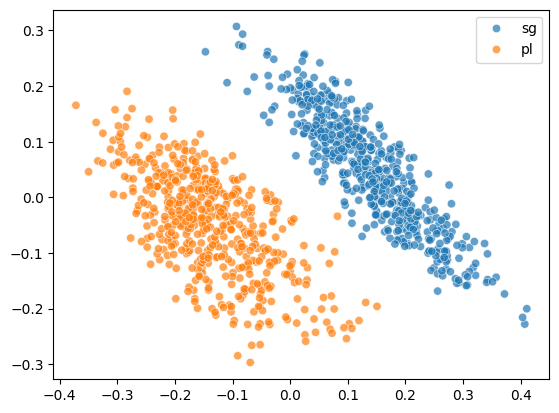

In [11]:
# pca to 2d
pca = PCA(n_components=2)
reduced = pca.fit_transform(combined)

sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=combined_labels, alpha=0.7)

In [ ]:
torch.stack(wug['init']).to(torch.float32) @ (sg_embs.mean(0) - pl_embs.mean(0)))

tensor([-0.0303, -0.0324, -0.0256, -0.0369, -0.0420, -0.0381, -0.0223, -0.0388,
        -0.0315, -0.0283, -0.0340, -0.0292, -0.0273, -0.0316, -0.0408, -0.0357,
        -0.0323, -0.0373, -0.0270, -0.0375, -0.0249, -0.0377, -0.0326, -0.0337,
        -0.0293, -0.0414, -0.0336, -0.0358, -0.0302, -0.0327, -0.0400, -0.0391,
        -0.0367, -0.0267, -0.0319, -0.0328, -0.0405, -0.0304, -0.0263, -0.0374,
        -0.0345, -0.0326, -0.0415, -0.0329, -0.0399, -0.0275, -0.0398, -0.0319,
        -0.0376])

In [56]:
def project(queries, sg = sg_embs, pl = pl_embs):
    diff_vec = sg.mean(0) - pl.mean(0)
    projection = queries @ diff_vec / torch.linalg.vector_norm(diff_vec)
    return projection

In [ ]:
emb_movement_wug = project(torch.stack(wug['final']).to(torch.float32)) - project(torch.stack(wug['init']).to(torch.float32))
emb_movement_wugs = project(torch.stack(wugs['init']).to(torch.float32)) - project(torch.stack(wugs['final']).to(torch.float32))

tensor([0.0943, 0.0624, 0.0870, 0.0490, 0.1414, 0.1169, 0.0810, 0.1342, 0.1276,
        0.0691, 0.0873, 0.1111, 0.1181, 0.1081, 0.1035, 0.0886, 0.0931, 0.0633,
        0.0527, 0.0746, 0.1312, 0.0787, 0.1003, 0.0693, 0.0861, 0.0867, 0.0916,
        0.0906, 0.0792, 0.0965, 0.1049, 0.1144, 0.1189, 0.0897, 0.1207, 0.0856,
        0.0930, 0.1222, 0.0881, 0.1105, 0.0737, 0.1064, 0.0760, 0.1384, 0.0937,
        0.1094, 0.0770, 0.0992, 0.0764])

In [ ]:
# demo loading:

torch.load('../results/CI_seed_runs/lr_ci_results_Qwen3-VL-4B-Instruct_text_lr0p001_50seeds/seed_388/syntax_alternating_lr0p001_seed388_ep50/initial_embeddings.pt')

{'epoch': 0,
 'wug_id': 151669,
 'wugs_id': 151670,
 'wug_embedding': tensor([ 0.0070, -0.0065, -0.0139,  ...,  0.0135, -0.0354, -0.0071],
        dtype=torch.bfloat16),
 'wugs_embedding': tensor([ 0.0087,  0.0273, -0.0493,  ..., -0.0071, -0.0356, -0.0094],
        dtype=torch.bfloat16),
 'added_tokens': [' [wug]', ' [wugs]'],
 'vocab_size': 151938,
 'model_name': 'Qwen/Qwen3-VL-4B-Instruct'}

In [ ]:
torch.load('../results/CI_seed_runs/lr_ci_results_Qwen3-VL-4B-Instruct_image_lr0p001_50seeds/seed_11485/_alternating_lr0p001_seed11485_ep50/learned_embeddings.pt')
'../results/CI_seed_runs/lr_ci_results_Qwen3-VL-4B-Instruct_image_lr0p001_50seeds/seed_11485/_alternating_lr001_seed11485_ep50/learned_embeddings.pt'

{'wug_id': 151669,
 'wugs_id': 151670,
 'wug_embedding': tensor([-0.0066,  0.0168,  0.0260,  ..., -0.0109, -0.0205, -0.0146],
        dtype=torch.bfloat16),
 'wugs_embedding': tensor([-0.0008, -0.0010, -0.0014,  ...,  0.0101, -0.0237, -0.0035],
        dtype=torch.bfloat16),
 'added_tokens': [' [wug]', ' [wugs]'],
 'vocab_size': 151938,
 'model_name': 'Qwen/Qwen3-VL-4B-Instruct',
 'saved_epoch': 15}

In [ ]:
# load wug and wugs
import os

dir = '../results/CI_seed_runs/lr_ci_results_Qwen3-VL-4B-Instruct_text_lr0p001_50seeds/'

# for each seed, load embeddings, separate wug and wugs, and save them separately
# infer seed from folder name, like in: '../results/CI_seed_runs/lr_ci_results_Qwen3-VL-4B-Instruct_text_lr0p001_50seeds/seed_388/syntax_alternating_lr0p001_seed388_ep50/learned_embeddings.pt'

if 'text' in dir:
    prefix = 'syntax'
else:
    prefix = ''

wug = {'init': [], 'final': []}
wugs = {'init': [], 'final': []}

for folder in os.listdir(dir):
    if folder.startswith('seed_'):
        seed = folder.split('_')[1]
        paths = {
            'init': os.path.join(dir, folder, f'{prefix}_alternating_lr0p001_seed{seed}_ep50', 'initial_embeddings.pt'),
            'final': os.path.join(dir, folder, f'{prefix}_alternating_lr0p001_seed{seed}_ep50', 'learned_embeddings.pt')
        }
        
        for key, emb_path in paths.items():
            # if os.path.exists(emb_path):
            embeddings = torch.load(emb_path)
            # separate wug and wugs
            wug_embs = embeddings['wug_embedding']
            wugs_embs = embeddings['wugs_embedding']

            wug[key].append(wug_embs)
            wugs[key].append(wugs_embs)

In [76]:
emb_movement_wug = project(torch.stack(wug['final']).to(torch.float32)) - project(torch.stack(wug['init']).to(torch.float32))
emb_movement_wugs = project(torch.stack(wugs['init']).to(torch.float32)) - project(torch.stack(wugs['final']).to(torch.float32))

# do this but with pca

sg_reduced = torch.tensor(reduced[:len(singulars)])
pl_reduced = torch.tensor(reduced[len(singulars):])

wug_reduced_init = torch.tensor(pca.transform(torch.stack(wug['init']).to(torch.float16).numpy())).to(torch.float32)
wugs_reduced_init = torch.tensor(pca.transform(torch.stack(wugs['init']).to(torch.float16).numpy())).to(torch.float32)
wug_reduced_final = torch.tensor(pca.transform(torch.stack(wug['final']).to(torch.float16).numpy())).to(torch.float32)
wugs_reduced_final = torch.tensor(pca.transform(torch.stack(wugs['final']).to(torch.float16).numpy())).to(torch.float32)

pca_movement_wug = project(wug_reduced_final, sg = sg_reduced, pl = pl_reduced) - project(wug_reduced_init, sg = sg_reduced, pl = pl_reduced)
pca_movement_wugs = project(wugs_reduced_init, sg = sg_reduced, pl = pl_reduced) - project(wugs_reduced_final, sg = sg_reduced, pl = pl_reduced)

In [78]:
# save sg and pl reduced in csv
def write_csv(filename, data, labels):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['x', 'y', 'label'])
        for (x, y), label in zip(data, labels):
            writer.writerow([x, y, label])

# pathlib.Path(f'../results/movement-analysis/{model_name}').mkdir(parents=True, exist_ok=True)
# write_csv(f'../results/movement-analysis/{model_name}/sg_pl_reduced.csv', reduced, combined_labels)

# save emb_movement for wug and wugs with sg and pl annotations as csv
def write_movement_csv(filename, wug_movement, wugs_movement):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['movement', 'type', 'number'])
        for movement in wug_movement:
            writer.writerow([movement.item(), 'wug', 'sg'])
        for movement in wugs_movement:
            writer.writerow([movement.item(), 'wugs', 'pl'])

# save wug and wugs reduced in csv but with pair ids maintained, along with whether it's init or final, and whether it's wug or wugs
def write_wug_wugs_csv(filename, wug_init, wug_final, wugs_init, wugs_final):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['x', 'y', 'type', 'stage', 'pair_id'])
        for i, (init, final) in enumerate(zip(wug_init, wug_final)):
            writer.writerow([init[0].item(), init[1].item(), 'wug', 'init', i])
            writer.writerow([final[0].item(), final[1].item(), 'wug', 'final', i])
        for i, (init, final) in enumerate(zip(wugs_init, wugs_final)):
            writer.writerow([init[0].item(), init[1].item(), 'wugs', 'init', i])
            writer.writerow([final[0].item(), final[1].item(), 'wugs', 'final', i])

# save it for the text and image conditions separately 
pathlib.Path(f'../results/movement-analysis/{model_name}').mkdir(parents=True, exist_ok=True)

if 'text' in dir:
    write_wug_wugs_csv(f'../results/movement-analysis/{model_name}/wug_wugs_reduced_text.csv', wug_reduced_init, wug_reduced_final, wugs_reduced_init, wugs_reduced_final)
    write_movement_csv(f'../results/movement-analysis/{model_name}/wug_wugs_movement_text.csv', pca_movement_wug, pca_movement_wugs)
else:
    write_wug_wugs_csv(f'../results/movement-analysis/{model_name}/wug_wugs_reduced_image.csv', wug_reduced_init, wug_reduced_final, wugs_reduced_init, wugs_reduced_final)
    write_movement_csv(f'../results/movement-analysis/{model_name}/wug_wugs_movement_image.csv', pca_movement_wug, pca_movement_wugs)


In [ ]:
len(wug), len(wugs)

(2, 2)

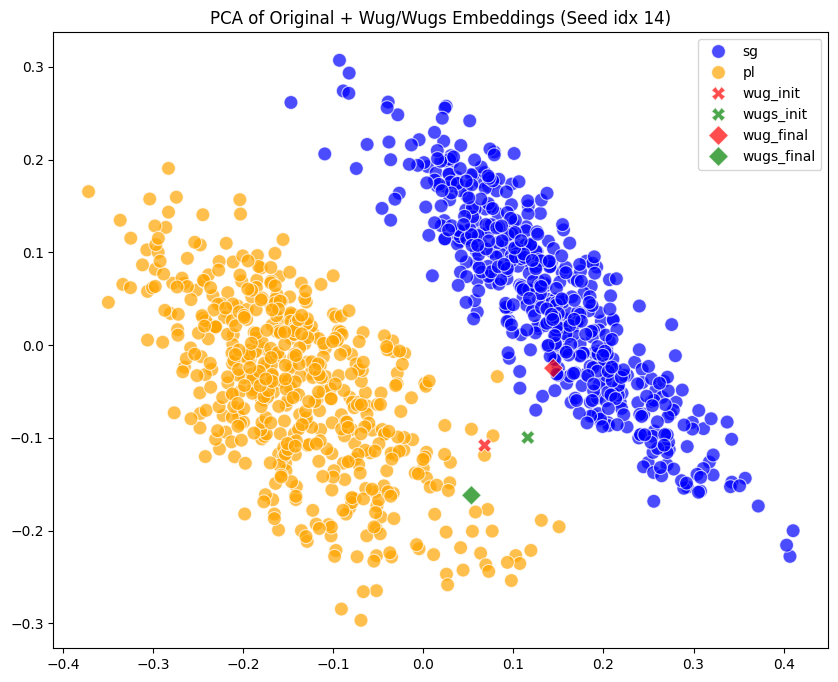

In [40]:
# plot both initial and final wug and wugs embeddings in the same PCA plot, with different colors and shapes for wug and wugs, and larger sizes for wug and wugs points.
# have different shapes for start and final points, and different colors for wug and wugs.

index = 14
wug_start_embs = wug['init'][index].to(torch.float16).unsqueeze(0).numpy()
wugs_start_embs = wugs['init'][index].to(torch.float16).unsqueeze(0).numpy()

wug_final_embs = wug['final'][index].to(torch.float16).unsqueeze(0).numpy()
wugs_final_embs = wugs['final'][index].to(torch.float16).unsqueeze(0).numpy()

wug_start_transformed = pca.transform(wug_start_embs)
wugs_start_transformed = pca.transform(wugs_start_embs)
wug_final_transformed = pca.transform(wug_final_embs)
wugs_final_transformed = pca.transform(wugs_final_embs)

reduced_combined = np.concatenate([reduced, wug_start_transformed, wugs_start_transformed, wug_final_transformed, wugs_final_transformed], axis=0)
combined_labels_extended = combined_labels + ['wug_init'] * len(wug_start_transformed) + ['wugs_init'] * len(wugs_start_transformed) + ['wug_final'] * len(wug_final_transformed) + ['wugs_final'] * len(wugs_final_transformed)
plt.figure(figsize=(10, 8))
# have different shapes for start and final points, and different colors for wug and wugs, and larger sizes for wug and wugs points.
sns.scatterplot(x=reduced_combined[:,0], y=reduced_combined[:,1], hue=combined_labels_extended, alpha=0.7, palette={'sg': 'blue', 'pl': 'orange', 'wug_init': 'red', 'wug_final': 'red', 'wugs_init': 'green', 'wugs_final': 'green'}, style=combined_labels_extended, markers={'sg': 'o', 'pl': 'o', 'wug_init': 'X', 'wug_final': 'D', 'wugs_init': 'X', 'wugs_final': 'D'}, s=100)
plt.title(f'PCA of Original + Wug/Wugs Embeddings (Seed idx {index})')
plt.legend()
plt.show() 

In [49]:
# visualize the plot in an interactive way to see which points are which words, using plotly, the points should show which word it is when hovered over, and wug and wugs should be bigger and have different shapes, and colored red and green respectively.
import plotly.express as px

words = singulars + plurals + ['wug'] * len(wug_transformed) + ['wugs'] * len(wugs_transformed)

# show words on hover, color wug and wugs with red and green colors, increase sizes for wug and wugs alone and mark then with different shapes.
fig = px.scatter(x=reduced_combined[:,0], y=reduced_combined[:,1], color=combined_labels_extended, symbol=combined_labels_extended, title=f'PCA of Original + Wug/Wugs Embeddings (Seed idx {index})', labels={'color': 'Category', 'symbol': 'Category'}, color_discrete_map={'sg': 'blue', 'pl': 'orange', 'wug': 'red', 'wugs': 'green'}, symbol_map={'sg': 'circle', 'pl': 'circle', 'wug': 'x', 'wugs': 'x'}, hover_name=words)
fig.update_traces(marker=dict(size=10))
fig.show()